# 19 — Frequency response & GPU FFT (`math`, SciPy, PyTorch, python-control)

Close the `1x` decade by checking that four pictures of \(H(j\omega)\) agree:

| Stack | Frequency response |
| --- | --- |
| python-control | `frequency_response` / Bode of \(H(s)\) |
| SciPy | `signal.bode` / `freqresp` |
| `math` | evaluate \(H(j\omega) = C(j\omega I-A)^{-1}B+D\) with stdlib `cmath` |
| PyTorch | `torch.fft.rfft` of a batched impulse response on `cuda` |

The DFT identity we use: for a sampled impulse \(h[k] \approx h(k\Delta t)\),

$$
H(j\\omega) \\approx \\Delta t \\sum_{k=0}^{N-1} h[k] e^{-j\\omega k\\Delta t} = \\Delta t\\,\\mathrm{rFFT}(h).
$$

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FS_HZ = 8_192
DURATION_S = 2.0
FN_HZ = 8.0
ZETA = 0.25
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
WN = 2.0 * math.pi * FN_HZ

t = np.arange(N, dtype=np.float64) / FS_HZ
G = ct.tf([WN**2], [1.0, 2.0 * ZETA * WN, WN**2])
print(G)
print(f"n = {N}   device = {device}")

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          2527
  --------------------
  s^2 + 25.13 s + 2527
n = 16384   device = cuda


## python-control Bode (the spec)

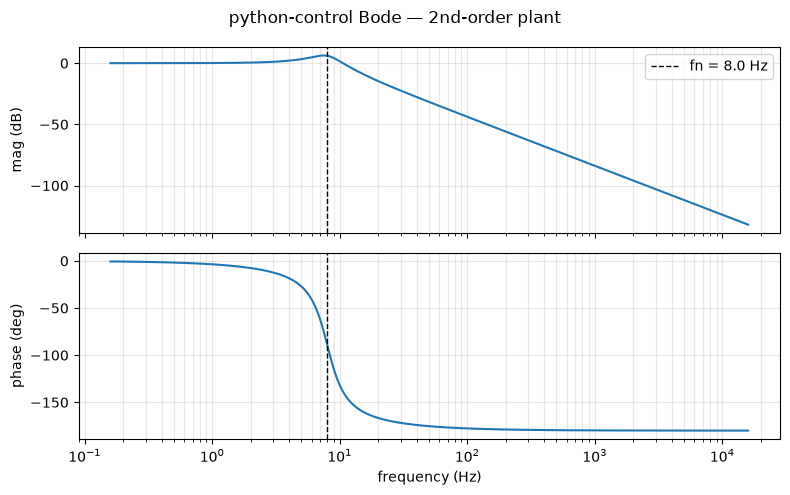

(array([1.00000000e+00, 1.02334021e+00, 1.04722519e+00, 1.07166765e+00,
        1.09668060e+00, 1.12227736e+00, 1.14847155e+00, 1.17527712e+00,
        1.20270833e+00, 1.23077980e+00, 1.25950646e+00, 1.28890361e+00,
        1.31898690e+00, 1.34977233e+00, 1.38127630e+00, 1.41351558e+00,
        1.44650734e+00, 1.48026913e+00, 1.51481892e+00, 1.55017512e+00,
        1.58635653e+00, 1.62338243e+00, 1.66127252e+00, 1.70004698e+00,
        1.73972643e+00, 1.78033202e+00, 1.82188534e+00, 1.86440853e+00,
        1.90792422e+00, 1.95245558e+00, 1.99802631e+00, 2.04466067e+00,
        2.09238348e+00, 2.14122015e+00, 2.19119669e+00, 2.24233968e+00,
        2.29467637e+00, 2.34823460e+00, 2.40304289e+00, 2.45913043e+00,
        2.51652705e+00, 2.57526333e+00, 2.63537052e+00, 2.69688063e+00,
        2.75982639e+00, 2.82424133e+00, 2.89015972e+00, 2.95761666e+00,
        3.02664806e+00, 3.09729067e+00, 3.16958209e+00, 3.24356081e+00,
        3.31926620e+00, 3.39673858e+00, 3.47601918e+00, 3.557150

In [4]:
omega = 2.0 * np.pi * np.logspace(-1, 3, 400)
w, mag_ct, phase_ct = bode_mag_phase(G, omega)
f_ct = w / (2.0 * np.pi)
plot_bode(G, "python-control Bode — 2nd-order plant", marks=[(FN_HZ, f"fn = {FN_HZ} Hz")])

## SciPy `signal.bode`

In [5]:
sys_sp = signal.TransferFunction([WN**2], [1.0, 2.0 * ZETA * WN, WN**2])
w_sp, mag_db_sp, phase_sp = signal.bode(sys_sp, w=omega)
print(f"scipy vs control mag (dB) max abs {np.max(np.abs(mag_db_sp - 20*np.log10(np.maximum(mag_ct, 1e-16)))):.3e}")

scipy vs control mag (dB) max abs 0.000e+00


## `math` — evaluate \(C(j\omega I-A)^{-1}B+D\) with `cmath`

2×2 inverse written out so there is no NumPy in the inner loop.

In [6]:
import cmath

ss = ct.tf2ss(G)
A, B, C, D = np.asarray(ss.A), np.asarray(ss.B), np.asarray(ss.C), np.asarray(ss.D)


def math_freqresp(omegas, A, B, C, D):
    a11, a12, a21, a22 = float(A[0, 0]), float(A[0, 1]), float(A[1, 0]), float(A[1, 1])
    b1, b2 = float(B[0, 0]), float(B[1, 0])
    c1, c2 = float(C[0, 0]), float(C[0, 1])
    d = float(D[0, 0])
    out = []
    for w in omegas:
        jw = 1j * float(w)
        m11 = jw - a11
        m12 = -a12
        m21 = -a21
        m22 = jw - a22
        det = m11 * m22 - m12 * m21
        i11 = m22 / det
        i12 = -m12 / det
        i21 = -m21 / det
        i22 = m11 / det
        x1 = i11 * b1 + i12 * b2
        x2 = i21 * b1 + i22 * b2
        out.append(c1 * x1 + c2 * x2 + d)
    return out


H_math = math_freqresp(omega, A, B, C, D)
mag_math = np.array([abs(h) for h in H_math], dtype=np.float64)
print("math vs control |H|", max_abs(mag_ct, mag_math))

math vs control |H| 4.440892098500626e-16


## PyTorch — batched impulse → `rfft`

One Euler impulse response per \(\zeta\), then a single `torch.fft.rfft` on the `(B, T)` buffer.

In [7]:
def torch_impulse_batch(dt, n, wn, zeta):
    # zeta: (B,); first sample of u is 1/dt so the area is 1 (discrete Dirac)
    B = zeta.numel()
    u = torch.zeros(B, n, device=zeta.device, dtype=zeta.dtype)
    u[:, 0] = 1.0 / dt
    x1 = torch.zeros(B, device=zeta.device, dtype=zeta.dtype)
    x2 = torch.zeros(B, device=zeta.device, dtype=zeta.dtype)
    two_z_wn = 2.0 * zeta * wn
    wn2 = wn * wn
    y = torch.empty(B, n, device=zeta.device, dtype=zeta.dtype)
    for i in range(n):
        dx1 = x2
        dx2 = -wn2 * x1 - two_z_wn * x2 + wn2 * u[:, i]
        x1 = x1 + dt * dx1
        x2 = x2 + dt * dx2
        y[:, i] = x1
    return y


zeta_grid = torch.tensor([0.10, 0.25, 0.50, 0.80], device=device, dtype=torch.float32)
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
h_b = torch_impulse_batch(DT, N, WN, zeta_grid)
H_b = torch.fft.rfft(h_b, dim=-1) * DT
freqs = torch.fft.rfftfreq(N, d=DT, device=device)
if device.type == "cuda":
    torch.cuda.synchronize()
print(f"impulse+rfft  B={h_b.shape[0]} T={N} on {H_b.device} in {(time.perf_counter()-t0)*1e3:.1f} ms")

i_nom = 1  # ζ = 0.25
f_np = freqs.detach().cpu().numpy()
mag_fft = H_b[i_nom].abs().detach().cpu().numpy()
# compare on the Bode grid by interpolation
mag_fft_i = np.interp(f_ct, f_np, mag_fft)
mask = (f_ct > 0.3) & (f_ct < 80.0)
rel = np.max(np.abs(mag_fft_i[mask] - mag_ct[mask]) / np.maximum(mag_ct[mask], 1e-6))
print(f"rFFT vs control relative |H| (0.3–80 Hz)  {rel:.3e}")
print(f"H.device = {H_b.device}")

impulse+rfft  B=4 T=16384 on cuda:0 in 1305.2 ms
rFFT vs control relative |H| (0.3–80 Hz)  1.232e-02
H.device = cuda:0


## Overlay Bode — analytic vs GPU FFT, plus a ζ family

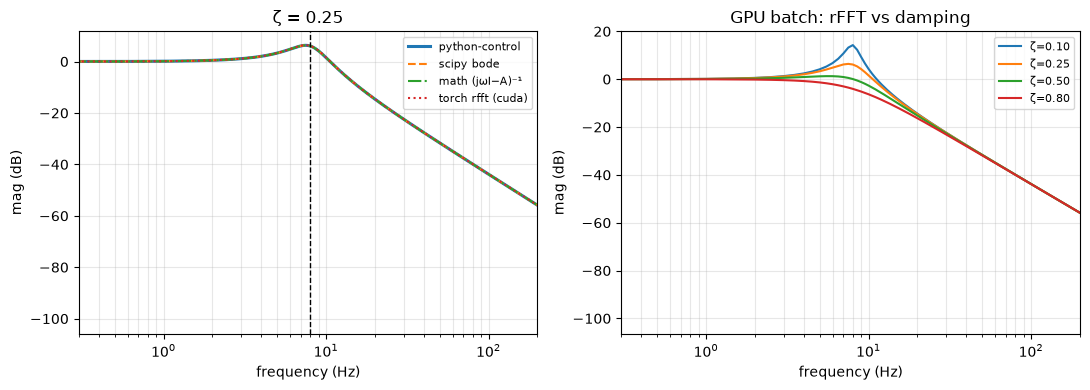

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(f_ct, 20 * np.log10(np.maximum(mag_ct, 1e-16)), lw=2.2, label="python-control")
axes[0].semilogx(f_ct, mag_db_sp, ls="--", label="scipy bode")
axes[0].semilogx(f_ct, 20 * np.log10(np.maximum(mag_math, 1e-16)), ls="-.", label="math (jωI−A)⁻¹")
axes[0].semilogx(f_np, 20 * np.log10(np.maximum(mag_fft, 1e-16)), ls=":", label=f"torch rfft ({device})")
axes[0].axvline(FN_HZ, color="k", ls="--", lw=1)
axes[0].set_xlim(0.3, 200)
axes[0].set_xlabel("frequency (Hz)")
axes[0].set_ylabel("mag (dB)")
axes[0].set_title(f"ζ = {ZETA}")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)

for i, z in enumerate(zeta_grid.tolist()):
    mag = H_b[i].abs().detach().cpu().numpy()
    axes[1].semilogx(f_np, 20 * np.log10(np.maximum(mag, 1e-16)), label=f"ζ={z:.2f}")
axes[1].set_xlim(0.3, 200)
axes[1].set_xlabel("frequency (Hz)")
axes[1].set_ylabel("mag (dB)")
axes[1].set_title("GPU batch: rFFT vs damping")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Takeaways

- Four stacks, one Bode: python-control, SciPy, `cmath` resolvent, `torch.fft.rfft`.
- Scale the DFT by \(\Delta t\) or the impulse-response FRF is off by \(f_s\).
- The GPU-native object is a **batched spectrum** (many \(\zeta\), many plants), not a single `forced_response`.
- That is the end of the `1x` decade. `20+` can swap these plants for identified models, LQR, or learned controllers without changing the signal / plant / Bode contract.